<a href="https://colab.research.google.com/github/bpickett14/AdvancedStatisticalMethods/blob/main/WrittenReportChapter2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Brenna Pickett Bunderson - Written Report 2

In [ ]:
install.packages('Sleuth3')
library('Sleuth3')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
head(ex0221)
attach(ex0221)

,Humerus,Status
,<dbl>,<fct>
1,0.687,Survived
2,0.703,Survived
3,0.709,Survived
4,0.715,Survived
5,0.728,Survived
6,0.721,Survived


The following objects are masked from ex0221 (pos = 7):

    Humerus, Status




#Introduction: Describe the Data and Present the Question

In 1899, biologist Hermon Bumpus presented measurements on house sparrows collected after a severe winter storm as evidence of natural selection. The birds were classified based on whether they survived or perished as a result of their injuries. The dataset contains humerus (arm bone) lengths, measured in inches, for 59 adult male sparrows, grouped according to survival status.

The purpose of this analysis is to examine whether the distribution of humerus lengths differs between sparrows that survived the storm and those that perished. By comparing these two groups, we seek to summarize the statistical evidence for an association between humerus length and survival, which would be consistent with natural selection acting on this physical characteristic.

# Graphical Analysis

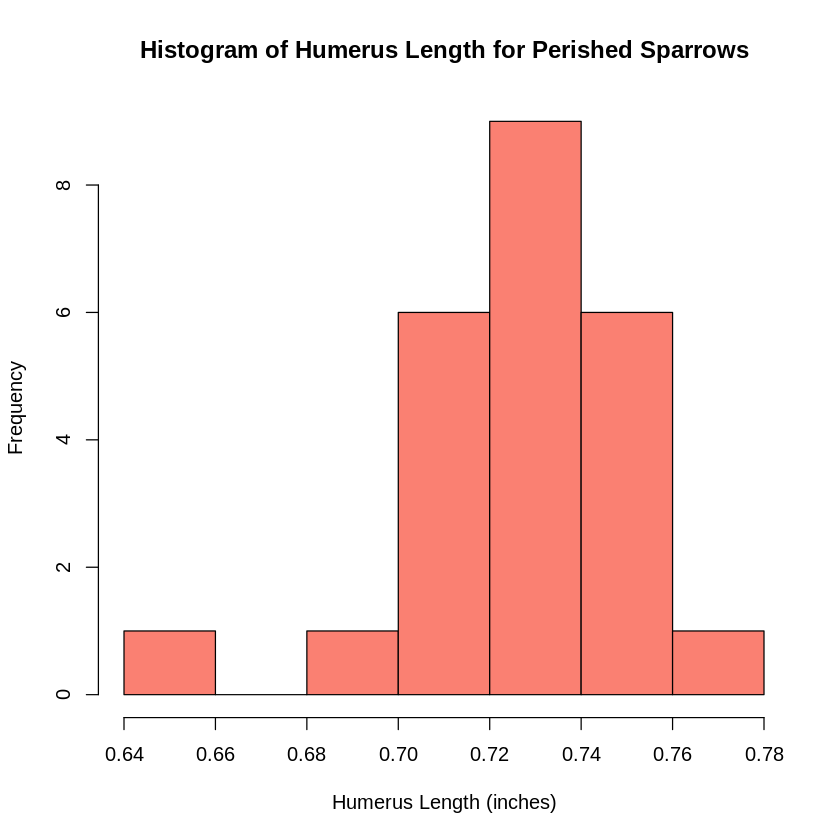

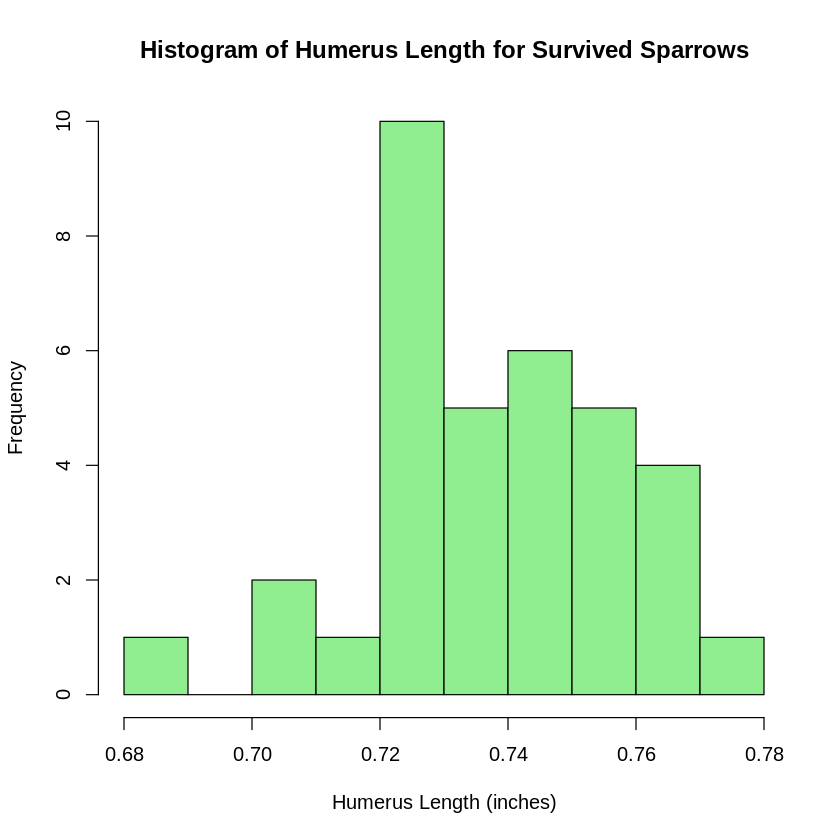

[1] "Mean Humerus Length for Perished Sparrows:"
[1] 0.7279167
[1] "Mean Humerus Length for Survived Sparrows:"
[1] 0.738
[1] "Five-number Summary for Perished Sparrows:"
[1] 0.6590 0.7165 0.7335 0.7435 0.7650
[1] "Five-number Summary for Survived Sparrows:"
[1] 0.6870 0.7280 0.7360 0.7515 0.7800


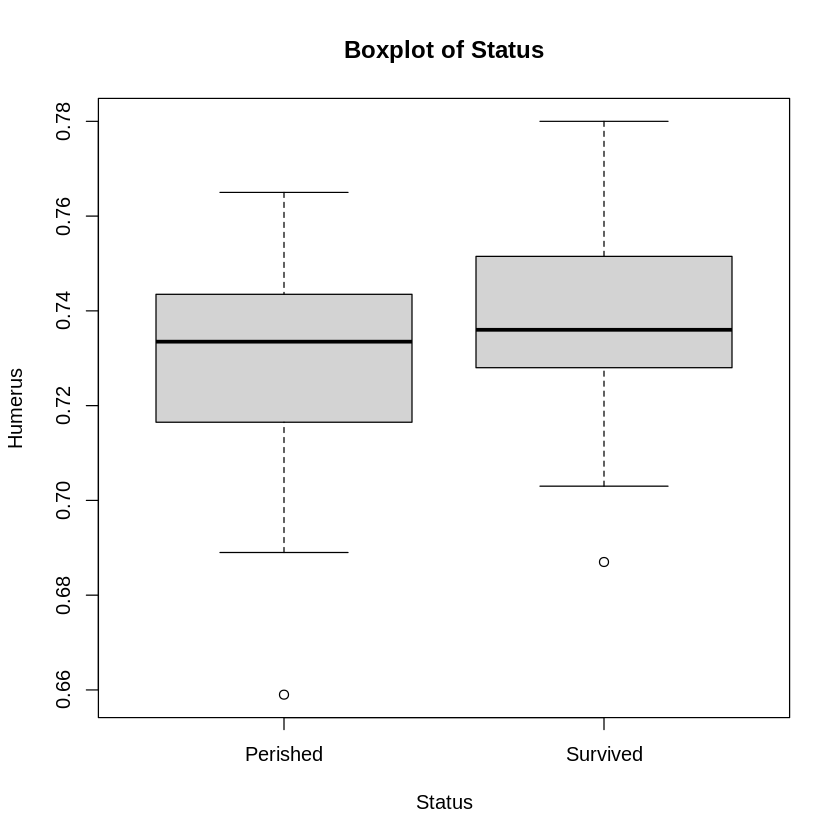

In [ ]:
# Extract Humerus length for Perished and Survived groups
Perished.Humerus <- ex0221 %>% filter(Status == 'Perished') %>% pull(Humerus)
Survived.Humerus <- ex0221 %>% filter(Status == 'Survived') %>% pull(Humerus)

# Histograms
hist(Perished.Humerus, main = 'Histogram of Humerus Length for Perished Sparrows', xlab = 'Humerus Length (inches)', col = 'salmon')
hist(Survived.Humerus, main = 'Histogram of Humerus Length for Survived Sparrows', xlab = 'Humerus Length (inches)', col = 'lightgreen')

boxplot(Humerus~Status, data = ex0221, main='Boxplot of Status')

# Means
print("Mean Humerus Length for Perished Sparrows:")
print(mean(Perished.Humerus))
print("Mean Humerus Length for Survived Sparrows:")
print(mean(Survived.Humerus))

# Five-number summary
print("Five-number Summary for Perished Sparrows:")
print(fivenum(Perished.Humerus))
print("Five-number Summary for Survived Sparrows:")
print(fivenum(Survived.Humerus))

#Assumptions
First, let's check normality:

In [ ]:
# Calculate the sample size for each group (Survived/Perished)
sample_sizes <- ex0221 %>%
  group_by(Status) %>%
  summarise(count = n())

# Display the sample sizes
print(sample_sizes)

# A tibble: 2 × 2
  Status   count
  <fct>    <int>
1 Perished    24
2 Survived    35


Since Perished is slightly below the standard 30, let's do the Shapiro test

In [ ]:
# Perform Shapiro-Wilk test for 'Perished' group
perished_humerus <- ex0221 %>%
  filter(Status == "Perished") %>%
  select(Humerus)
shapiro_perished <- shapiro.test(perished_humerus$Humerus)
print(shapiro_perished)

# Perform Shapiro-Wilk test for 'Survived' group
survived_humerus <- ex0221 %>%
  filter(Status == "Survived") %>%
  select(Humerus)
shapiro_survived <- shapiro.test(survived_humerus$Humerus)
print(shapiro_survived)


	Shapiro-Wilk normality test

data:  perished_humerus$Humerus
W = 0.9295, p-value = 0.09502


	Shapiro-Wilk normality test

data:  survived_humerus$Humerus
W = 0.98105, p-value = 0.7929



This is pretty close (at least for perished), but with a perished p-value of 0.09502 and a survived p-value of 0.7929, I think it's safe to fail to reject the null hypothesis for both survived and perished where the null is that the data is normally distributed and the alternative is that it is not normally distributed. These samples are normally distributed.

Let's move on to variance. The box plots look fairly equal in their variance, but let's check with a Levene's Test.

In [ ]:
install.packages('car')
library(car)

# Perform Levene's test for equality of variances
levene_test_result <- leveneTest(Humerus ~ Status, data = ex0221)

# Print the results of Levene's test
print("Levene's Test for Equality of Variances:")
print(levene_test_result)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Levene's Test for Equality of Variances:"
Levene's Test for Homogeneity of Variance (center = median)
      Df F value Pr(>F)
group  1  0.3151 0.5768
      57               


Since the p-value is quite large (0.5768), we fail to reject the null hypothesis. The null hypothesis is that the variances are equal, and the alternative is they aren't. We can consider the variances to be equal!

As for independence, the observations of humerus length for each sparrow can be considered independent because each bird’s survival and measurement were recorded separately, and there is no indication that one bird’s outcome affected another’s in the dataset.

#Statistical Conclusion

In [ ]:
# Perform independent two-sample t-test assuming equal variances
t.test(Humerus ~ Status, data = ex0221, var.equal = TRUE, alternative = "two.sided")


	Two Sample t-test

data:  Humerus by Status
t = -1.777, df = 57, p-value = 0.0809
alternative hypothesis: true difference in means between group Perished and group Survived is not equal to 0
95 percent confidence interval:
 -0.021446053  0.001279386
sample estimates:
mean in group Perished mean in group Survived 
             0.7279167              0.7380000 


A two-sample t-test was conducted to assess whether the mean humerus length differed between male house sparrows that perished and those that survived the severe winter storm. The null hypothesis stated that the mean humerus length was the same in both groups, while the alternative hypothesis proposed a difference. The t-test assumes approximate normality, equal variances, and independence of observations; these assumptions were checked and found reasonable based on Shapiro-Wilk and Levene’s tests.

The resulting p-value was 0.0809, which is suggestive but not conclusive or statistically significant at the 0.05 level. The 95% confidence interval for the difference in means is -0.02144 to 0.00128. Because this interval includes zero, we cannot conclusively state that the mean humerus lengths differ between the two groups. However, the interval leans slightly negative, indicating that the sparrows that perished may have had, on average, shorter humerus lengths than those that survived. This provides some evidence consistent with the idea that larger humerus length could be associated with higher survival, though the evidence is not strong enough to draw definitive conclusions.

#Scope of Inference
Since these data were collected in 1899 from adult male house sparrows, the conclusions apply only to similar sparrows from that time period. The analysis suggests a possible association between humerus length and survival, but the evidence is not strong enough to be conclusive.

This is an observational study because the researchers did not assign birds to perish or survive (that would be pretty weird); instead, outcomes were observed following a naturally occurring winter storm.

In [ ]:
detach(ex0221)